# K-mer frequency spectra across alphabets and ksizes

Data: `~/data/kmerseek-kmer-spectra/`, produced by `nextflow-runs/kmer-spectra/main.nf` running `kmerseek index --kmer-stats-out` over Swiss-Prot for every (alphabet, ksize) combo. Each file is a k-mer occurrence histogram (how many distinct k-mers occur 1x, 2x, 3x, ... times across the proteome), with summary stats in a `#`-prefixed header line.

In [1]:
import gzip
import re
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

DATA_DIR = Path.home() / "data" / "kmerseek-kmer-spectra"
FIG_DIR = Path(".")

plt.rcParams["figure.dpi"] = 100


In [2]:
HEADER_RE = re.compile(
    r"total_kmers=(?P<total_kmers>\d+)\s+"
    r"unique_kmers=(?P<unique_kmers>\d+)\s+"
    r"mean_seqs_per_kmer=(?P<mean_seqs_per_kmer>[\d.]+)\s+"
    r"median_seqs_per_kmer=(?P<median_seqs_per_kmer>[\d.]+)\s+"
    r"moltype=(?P<moltype>\S+)\s+"
    r"ksize=(?P<ksize>\d+)"
)


def parse_header(path: Path) -> dict:
    with gzip.open(path, "rt") as fh:
        first_line = fh.readline()
    m = HEADER_RE.search(first_line)
    if m is None:
        raise ValueError(f"Could not parse header of {path}: {first_line!r}")
    d = m.groupdict()
    return {
        "moltype": d["moltype"],
        "ksize": int(d["ksize"]),
        "total_kmers": int(d["total_kmers"]),
        "unique_kmers": int(d["unique_kmers"]),
        "mean_seqs_per_kmer": float(d["mean_seqs_per_kmer"]),
        "median_seqs_per_kmer": float(d["median_seqs_per_kmer"]),
    }


def load_histogram(path: Path) -> pl.DataFrame:
    return pl.read_csv(path, comment_prefix="#")


spectrum_files = sorted(DATA_DIR.glob("sprot.*.spectrum.csv.gz"))
print(f"Found {len(spectrum_files)} spectrum files")
spectrum_files[:3]


Found 134 spectrum files


[PosixPath('/Users/olga/data/kmerseek-kmer-spectra/sprot.dayhoff.k10.spectrum.csv.gz'),
 PosixPath('/Users/olga/data/kmerseek-kmer-spectra/sprot.dayhoff.k11.spectrum.csv.gz'),
 PosixPath('/Users/olga/data/kmerseek-kmer-spectra/sprot.dayhoff.k12.spectrum.csv.gz')]

In [3]:
summary_df = pl.DataFrame([parse_header(p) for p in spectrum_files]).sort(["moltype", "ksize"])

# Redundancy: what fraction of all k-mer occurrences collapse onto fewer unique k-mers.
# Lower unique_kmers/total_kmers at fixed ksize means the alphabet compresses more.
summary_df = summary_df.with_columns(
    (pl.col("unique_kmers") / pl.col("total_kmers")).alias("unique_fraction")
)

print(summary_df.shape)
summary_df


(134, 7)


moltype,ksize,total_kmers,unique_kmers,mean_seqs_per_kmer,median_seqs_per_kmer,unique_fraction
str,i64,i64,i64,f64,f64,f64
"""dayhoff""",10,172339558,14848084,11.6069,3.0,0.086156
"""dayhoff""",11,172084420,33976195,5.0649,2.0,0.197439
"""dayhoff""",12,171752076,58988034,2.9116,1.0,0.343449
"""dayhoff""",13,171378861,80110845,2.1393,1.0,0.467449
"""dayhoff""",14,170983997,92775115,1.843,1.0,0.542595
…,…,…,…,…,…,…
"""protein""",11,179343169,118428118,1.5144,1.0,0.660344
"""protein""",12,178888285,120695883,1.4821,1.0,0.6747
"""protein""",13,178429587,122660599,1.4547,1.0,0.687445


## Figure 1: unique k-mer count vs ksize, by alphabet

How fast does the observed k-mer vocabulary grow with ksize for each alphabet? A reduced alphabet (HP, dayhoff) should saturate at far fewer unique k-mers than the full 20-letter protein alphabet at the same ksize. `hp_shuffled_control` is *not* a sequence-shuffle — it applies the real, unmodified Swiss-Prot sequences to a randomly scrambled amino-acid-to-H/P partition (h: `ADGKLMQRWY`, p: `CEFHINPSTV`, frozen for reproducibility in kmerseek's `hp_alphabets.rs`), as opposed to the biologically-motivated partitions (Lehninger, Thomas-Dill, Kyte-Doolittle, PBotC) used by the other HP variants.</cell id="4c8e4757">

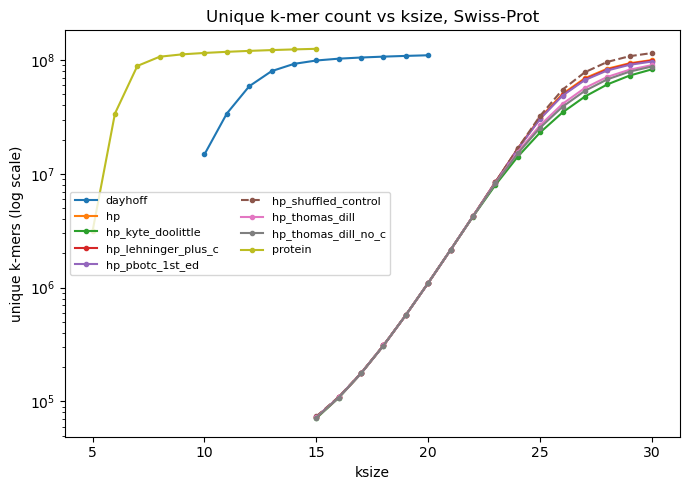

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
for moltype, group in summary_df.group_by("moltype", maintain_order=True):
    moltype = moltype[0]
    g = group.sort("ksize")
    linestyle = "--" if moltype == "hp_shuffled_control" else "-"
    ax.plot(g["ksize"], g["unique_kmers"], marker="o", markersize=3, linestyle=linestyle, label=moltype)

ax.set_yscale("log")
ax.set_xlabel("ksize")
ax.set_ylabel("unique k-mers (log scale)")
ax.set_title("Unique k-mer count vs ksize, Swiss-Prot")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIG_DIR / "24_unique_kmers_vs_ksize_by_alphabet.png", dpi=150, bbox_inches="tight")


## Figure 2: mean k-mer degeneracy vs ksize, by alphabet

`mean_seqs_per_kmer` is `total_kmers / unique_kmers` — the average number of proteome occurrences sharing each distinct k-mer. Higher values mean more collisions/degeneracy at that ksize. This is the number that matters for search specificity: an alphabet+ksize combo with high mean degeneracy will have more spurious k-mer matches between unrelated sequences.

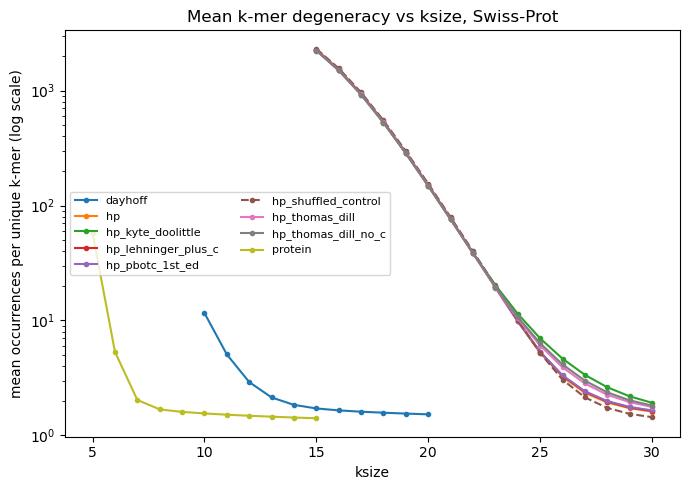

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
for moltype, group in summary_df.group_by("moltype", maintain_order=True):
    moltype = moltype[0]
    g = group.sort("ksize")
    linestyle = "--" if moltype == "hp_shuffled_control" else "-"
    ax.plot(g["ksize"], g["mean_seqs_per_kmer"], marker="o", markersize=3, linestyle=linestyle, label=moltype)

ax.set_yscale("log")
ax.set_xlabel("ksize")
ax.set_ylabel("mean occurrences per unique k-mer (log scale)")
ax.set_title("Mean k-mer degeneracy vs ksize, Swiss-Prot")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIG_DIR / "24_mean_degeneracy_vs_ksize_by_alphabet.png", dpi=150, bbox_inches="tight")


## Figure 3: HP-family degeneracy relative to the scrambled-partition null

For each HP variant (`hp`, `hp_kyte_doolittle`, `hp_lehninger_plus_c`, `hp_thomas_dill`, `hp_thomas_dill_no_c`, `hp_pbotc_1st_ed`), divide its `mean_seqs_per_kmer` by `hp_shuffled_control`'s at the same ksize. `hp_shuffled_control` is the real Swiss-Prot sequences encoded with a randomly scrambled amino-acid-to-H/P partition (see Figure 1), not a sequence-order shuffle — so this ratio isolates the effect of *which* partition is used, holding the real sequence and its real internal correlations fixed.

**Caution reading this ratio** (worked out in the section after Figure 4): `mean_seqs_per_kmer` here is not raw occurrence count. kmerseek's `--kmer-stats-out` increments a k-mer's count once per *protein* whose MinHash sketch contains it (a document-frequency-style count, from `index.rs` in the `kmer-frequency-histogram` branch), not once per sliding window. A ratio below 1 therefore does not mean "real HP patterning is no more repetitive than chance" — see below for what it actually reflects.</cell id="87cc693c">

shape: (6, 2)
┌─────────────────────┬──────────────────────────────┐
│ moltype             ┆ degeneracy_ratio_vs_shuffled │
│ ---                 ┆ ---                          │
│ str                 ┆ f64                          │
╞═════════════════════╪══════════════════════════════╡
│ hp                  ┆ 0.971056                     │
│ hp_kyte_doolittle   ┆ 0.955772                     │
│ hp_lehninger_plus_c ┆ 0.971523                     │
│ hp_pbotc_1st_ed     ┆ 0.963734                     │
│ hp_thomas_dill      ┆ 0.959302                     │
│ hp_thomas_dill_no_c ┆ 0.956819                     │
└─────────────────────┴──────────────────────────────┘


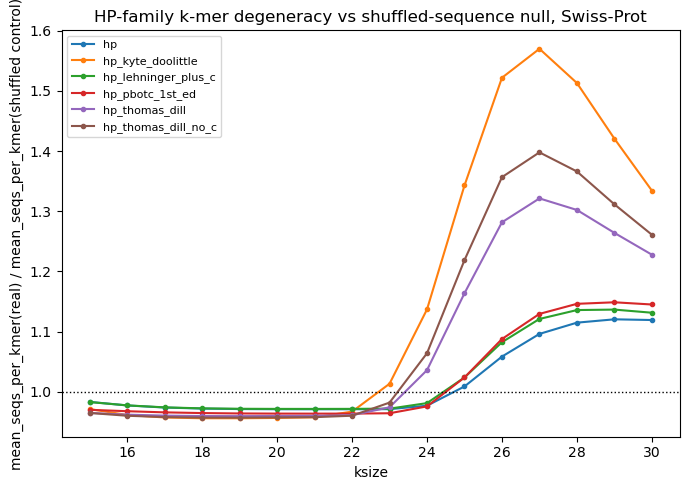

In [6]:
hp_variants = [
    "hp",
    "hp_kyte_doolittle",
    "hp_lehninger_plus_c",
    "hp_thomas_dill",
    "hp_thomas_dill_no_c",
    "hp_pbotc_1st_ed",
]

control = summary_df.filter(pl.col("moltype") == "hp_shuffled_control").select(
    "ksize", pl.col("mean_seqs_per_kmer").alias("control_mean_seqs_per_kmer")
)

ratio_df = (
    summary_df.filter(pl.col("moltype").is_in(hp_variants))
    .join(control, on="ksize", how="inner")
    .with_columns((pl.col("mean_seqs_per_kmer") / pl.col("control_mean_seqs_per_kmer")).alias("degeneracy_ratio_vs_shuffled"))
    .sort(["moltype", "ksize"])
)

fig, ax = plt.subplots(figsize=(7, 5))
for moltype, group in ratio_df.group_by("moltype", maintain_order=True):
    moltype = moltype[0]
    g = group.sort("ksize")
    ax.plot(g["ksize"], g["degeneracy_ratio_vs_shuffled"], marker="o", markersize=3, label=moltype)

ax.axhline(1.0, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("ksize")
ax.set_ylabel("mean_seqs_per_kmer(real) / mean_seqs_per_kmer(shuffled control)")
ax.set_title("HP-family k-mer degeneracy vs shuffled-sequence null, Swiss-Prot")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "24_hp_degeneracy_ratio_vs_shuffled_control.png", dpi=150, bbox_inches="tight")

print(ratio_df.filter(pl.col("ksize") == 19).select("moltype", "degeneracy_ratio_vs_shuffled"))


## Figure 4: occurrence-histogram shape at ksize=19

The full histogram (occurrences -> n_kmers with that occurrence count) shows the *shape* of degeneracy, not just its mean. ksize=19 is available for every HP-family alphabet and is the designated best ksize for `hp_pbotc_1st_ed`. Note `hp_shuffled_control` is the scrambled-partition null described in Figure 1, not a sequence shuffle.

The x-axis, "occurrences," is a document-frequency count (see the section below): how many distinct proteins' MinHash sketches contain that k-mer, not how many times it appears across all sliding windows.</cell id="d86c6365">

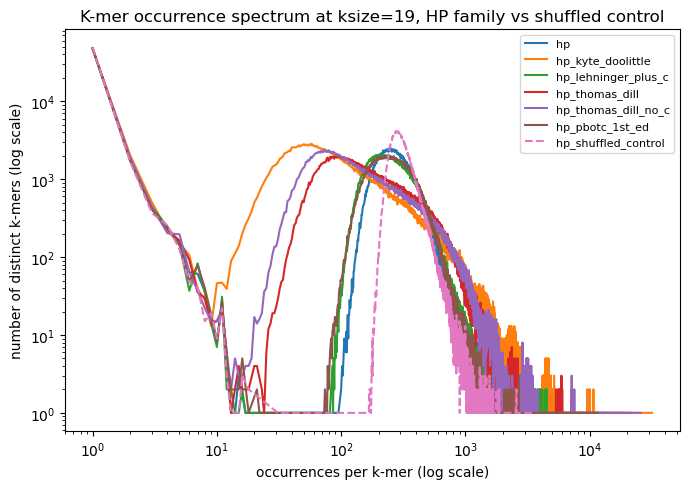

In [7]:
ksize_fixed = 19
moltypes_fixed = hp_variants + ["hp_shuffled_control"]

path_by_moltype = {parse_header(p)["moltype"]: p for p in spectrum_files if parse_header(p)["ksize"] == ksize_fixed}

fig, ax = plt.subplots(figsize=(7, 5))
for moltype in moltypes_fixed:
    path = path_by_moltype.get(moltype)
    if path is None:
        continue
    hist = load_histogram(path).sort("occurrences")
    linestyle = "--" if moltype == "hp_shuffled_control" else "-"
    ax.plot(hist["occurrences"], hist["n_kmers"], linestyle=linestyle, label=moltype)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("occurrences per k-mer (log scale)")
ax.set_ylabel("number of distinct k-mers (log scale)")
ax.set_title(f"K-mer occurrence spectrum at ksize={ksize_fixed}, HP family vs shuffled control")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / f"24_occurrence_histogram_k{ksize_fixed}_hp_family_vs_control.png", dpi=150, bbox_inches="tight")


## Why `hp_pbotc_1st_ed` (and every named HP alphabet) sits below the shuffled-partition null

Figure 3 shows every biologically-motivated HP variant with a degeneracy ratio below 1 at ksize <= 22. That looks backwards if you read "shuffled_control" as a "no structure" null: real, biologically patterned sequences should be *more* repetitive than an arbitrary control, not less.

The resolution is in how `total_kmers` is defined, traced from kmerseek's `kmer-frequency-histogram` branch (`index.rs`, `save_inverted_index`): for every protein, it takes that protein's MinHash sketch — a *deduplicated set* of the protein's distinct k-mers — and increments each k-mer's counter once per protein that contains it. So:

- `total_kmers` = sum over proteins of (number of *distinct* k-mers in that protein), not sum of all sliding windows.
- `unique_kmers` (proteome-wide distinct k-mer vocabulary) is nearly identical across all 7 alphabets at a given ksize (574k-576k at k=19 — see the table below), because with ~170M k-mer instances against only 2^19 = 524,288 possible binary strings, virtually every reachable pattern gets hit at least once regardless of composition.
- So `mean_seqs_per_kmer = total_kmers / unique_kmers` is driven almost entirely by `total_kmers`, i.e. by how many *distinct* k-mers survive deduplication within individual proteins.

A biologically-motivated H/P partition groups amino acids that really do co-occur in local structural contexts (hydrophobic cores, polar loops, etc.), so encoding a real protein with it produces longer runs of the same symbol -- fewer distinct k-mers survive per protein. A scrambled partition breaks those real local correlations apart, so the *same* real sequences look more locally diverse under it, and more distinct k-mers survive per protein.

That means the ratio-below-1 result is not "real HP patterning is unremarkable" -- it is the opposite: it is what you'd expect if the named partitions are capturing real, compressible local structure that an arbitrary partition does not. This is verified directly below from raw sequences (independent of any inference from the header stats).

In [8]:
# H/P tables, sourced directly from kmerseek:
#   hp                    -- REFERENCE_sourmash/src/core/src/encodings.rs, HPTABLE (sourmash built-in)
#   all other variants     -- src/rust/hp_alphabets.rs (kmerseek-kmer-frequency-histogram branch)
HP_TABLES = {
    "hp": {**{r: "h" for r in "AFGILMPVWY"}, **{r: "p" for r in "CDEHKNQRST"}},
    "hp_thomas_dill": {**{r: "h" for r in "ACFILMVWY"}, **{r: "p" for r in "DEGHKNPQRST"}},
    "hp_kyte_doolittle": {**{r: "h" for r in "ACFILMV"}, **{r: "p" for r in "DEGHKNPQRSTWY"}},
    "hp_thomas_dill_no_c": {**{r: "h" for r in "AFILMVWY"}, **{r: "p" for r in "CDEGHKNPQRST"}},
    "hp_lehninger_plus_c": {**{r: "h" for r in "ACFGILMPVWY"}, **{r: "p" for r in "DEHKNQRST"}},
    "hp_pbotc_1st_ed": {**{r: "h" for r in "ACFILMPVWY"}, **{r: "p" for r in "DEGHKNQRST"}},
    "hp_shuffled_control": {**{r: "h" for r in "ADGKLMQRWY"}, **{r: "p" for r in "CEFHINPSTV"}},
}

k19_table = summary_df.filter((pl.col("ksize") == 19) & (pl.col("moltype").is_in(HP_TABLES))).sort(
    "total_kmers", descending=True
)
print(k19_table.select("moltype", "total_kmers", "unique_kmers", "mean_seqs_per_kmer"))


shape: (7, 4)
┌─────────────────────┬─────────────┬──────────────┬────────────────────┐
│ moltype             ┆ total_kmers ┆ unique_kmers ┆ mean_seqs_per_kmer │
│ ---                 ┆ ---         ┆ ---          ┆ ---                │
│ str                 ┆ i64         ┆ i64          ┆ f64                │
╞═════════════════════╪═════════════╪══════════════╪════════════════════╡
│ hp_shuffled_control ┆ 171291308   ┆ 575716       ┆ 297.5274           │
│ hp_lehninger_plus_c ┆ 166142286   ┆ 574778       ┆ 289.0547           │
│ hp                  ┆ 166067392   ┆ 574795       ┆ 288.9159           │
│ hp_pbotc_1st_ed     ┆ 164818686   ┆ 574807       ┆ 286.7374           │
│ hp_thomas_dill      ┆ 164006170   ┆ 574616       ┆ 285.4187           │
│ hp_thomas_dill_no_c ┆ 163563131   ┆ 574551       ┆ 284.6799           │
│ hp_kyte_doolittle   ┆ 163324414   ┆ 574341       ┆ 284.3684           │
└─────────────────────┴─────────────┴──────────────┴────────────────────┘


### Direct verification: per-protein k-mer diversity fraction

For a random sample of real Swiss-Prot proteins, encode each one under all 7 tables and compute `n_distinct_kmers / n_sliding_windows` per protein -- exactly the quantity kmerseek's MinHash-based `total_kmers` count is built from, computed here independently and directly from sequence, not inferred from the spectrum files. If the mechanism above is right, `hp_shuffled_control` should have the *highest* mean diversity fraction (least within-protein repetition) and the alphabets that group real physicochemically-correlated residues together should sit measurably lower.

In [9]:
import random

FASTA_PATH = Path.home() / "data" / "uniprot" / "uniprot_sprot.fasta.gz"

seqs = []
with gzip.open(FASTA_PATH, "rt") as fh:
    chunks = []
    for line in fh:
        line = line.strip()
        if line.startswith(">"):
            if chunks:
                seqs.append("".join(chunks))
            chunks = []
        else:
            chunks.append(line)
    if chunks:
        seqs.append("".join(chunks))

print(f"total proteins in Swiss-Prot: {len(seqs)}")

random.seed(0)
k = 19
sample = random.sample([s for s in seqs if len(s) >= k + 1], 5000)

diversity_records = []
for name, table in HP_TABLES.items():
    fractions = []
    for s in sample:
        encoded = "".join(table.get(aa, "X") for aa in s)
        n_windows = len(encoded) - k + 1
        n_distinct = len({encoded[i : i + k] for i in range(n_windows)})
        fractions.append(n_distinct / n_windows)
    diversity_records.append(
        {"moltype": name, "mean_diversity_fraction": sum(fractions) / len(fractions), "n_proteins": len(fractions)}
    )

diversity_df = pl.DataFrame(diversity_records).sort("mean_diversity_fraction", descending=True)
print(diversity_df)


total proteins in Swiss-Prot: 572970


shape: (7, 3)
┌─────────────────────┬─────────────────────────┬────────────┐
│ moltype             ┆ mean_diversity_fraction ┆ n_proteins │
│ ---                 ┆ ---                     ┆ ---        │
│ str                 ┆ f64                     ┆ i64        │
╞═════════════════════╪═════════════════════════╪════════════╡
│ hp_shuffled_control ┆ 0.998528                ┆ 5000       │
│ hp_pbotc_1st_ed     ┆ 0.997351                ┆ 5000       │
│ hp                  ┆ 0.997237                ┆ 5000       │
│ hp_lehninger_plus_c ┆ 0.99699                 ┆ 5000       │
│ hp_thomas_dill      ┆ 0.996449                ┆ 5000       │
│ hp_thomas_dill_no_c ┆ 0.996097                ┆ 5000       │
│ hp_kyte_doolittle   ┆ 0.995137                ┆ 5000       │
└─────────────────────┴─────────────────────────┴────────────┘


Pearson r=0.8754, p=0.0098  (n=7 alphabets)


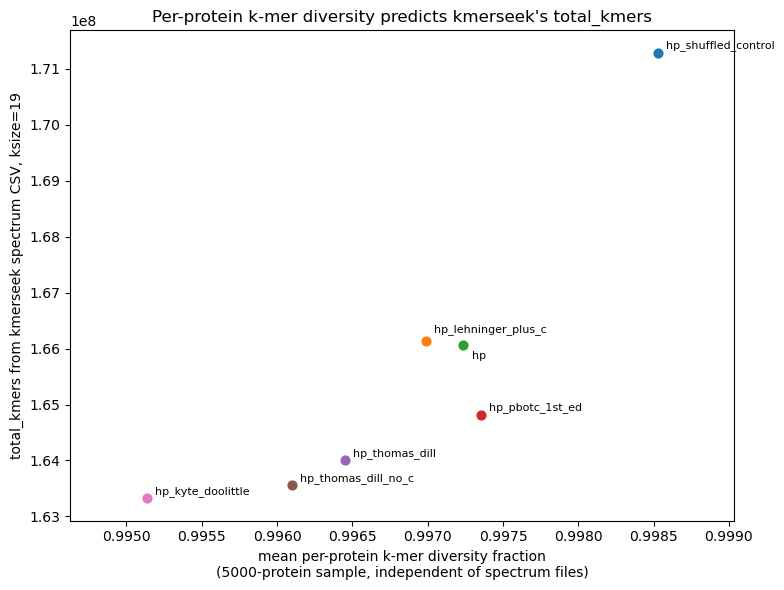

In [10]:
from scipy import stats

merged = diversity_df.join(k19_table.select("moltype", "total_kmers"), on="moltype")
r, p = stats.pearsonr(merged["mean_diversity_fraction"], merged["total_kmers"])
print(f"Pearson r={r:.4f}, p={p:.4f}  (n={merged.shape[0]} alphabets)")

fig, ax = plt.subplots(figsize=(8, 6))
offsets = {
    "hp": (6, -10),
    "hp_lehninger_plus_c": (6, 6),
}
for row in merged.iter_rows(named=True):
    ax.scatter(row["mean_diversity_fraction"], row["total_kmers"], s=40)
    dx, dy = offsets.get(row["moltype"], (6, 3))
    ax.annotate(
        row["moltype"],
        (row["mean_diversity_fraction"], row["total_kmers"]),
        fontsize=8,
        xytext=(dx, dy),
        textcoords="offset points",
    )

ax.set_xlabel("mean per-protein k-mer diversity fraction\n(5000-protein sample, independent of spectrum files)")
ax.set_ylabel("total_kmers from kmerseek spectrum CSV, ksize=19")
ax.set_title("Per-protein k-mer diversity predicts kmerseek's total_kmers")
ax.margins(x=0.15)
fig.tight_layout()
fig.savefig(FIG_DIR / "24_diversity_fraction_vs_total_kmers.png", dpi=150, bbox_inches="tight")


## Figure 5: HP space (2^k) vs proteome size vs ksize

A different framing of Figures 1-2: instead of just plotting the observed counts, compare them to the *theoretical* ceiling. For a 2-symbol (H/P) alphabet there are exactly `2^k` possible distinct k-mers of length k -- the entire "HP space." Two real quantities compete against that ceiling:

- `total_kmers`: how many (protein, k-mer) pairs kmerseek counted (see the document-frequency explanation above) -- roughly flat across ksize, since it is set by the proteome's size, not k.
- `unique_kmers`: how many of the `2^k` possible patterns were actually observed at least once.

At low ksize, `2^k` is tiny compared to `total_kmers`, so essentially every possible pattern is observed, many times over -- a saturated regime. As ksize grows, `2^k` grows exponentially while `total_kmers` stays roughly flat, so the two curves cross. Past that crossover, most of the `2^k` possible patterns are never observed at all -- `unique_kmers` falls further and further below `2^k`, because there simply isn't enough sequence to sample the full space. This uses `hp` as a representative alphabet: `total_kmers` only varies by ~5% across all 7 HP variants at fixed ksize (see the table two cells up), so a single curve captures the whole family.

shape: (16, 6)
┌───────┬────────────┬─────────────┬──────────────┬──────────────────┬───────────────────┐
│ ksize ┆ hp_space   ┆ total_kmers ┆ unique_kmers ┆ total_over_space ┆ unique_over_space │
│ ---   ┆ ---        ┆ ---         ┆ ---          ┆ ---              ┆ ---               │
│ i64   ┆ i32        ┆ i64         ┆ i64          ┆ f64              ┆ f64               │
╞═══════╪════════════╪═════════════╪══════════════╪══════════════════╪═══════════════════╡
│ 15    ┆ 32768      ┆ 165059303   ┆ 72543        ┆ 5037.210175      ┆ 2.213837          │
│ 16    ┆ 65536      ┆ 165939087   ┆ 108613       ┆ 2532.029526      ┆ 1.657303          │
│ 17    ┆ 131072     ┆ 166252293   ┆ 176936       ┆ 1268.404335      ┆ 1.349915          │
│ 18    ┆ 262144     ┆ 166249163   ┆ 310440       ┆ 634.190228       ┆ 1.184235          │
│ 19    ┆ 524288     ┆ 166067392   ┆ 574795       ┆ 316.748413       ┆ 1.096334          │
│ …     ┆ …          ┆ …           ┆ …            ┆ …                ┆ …   

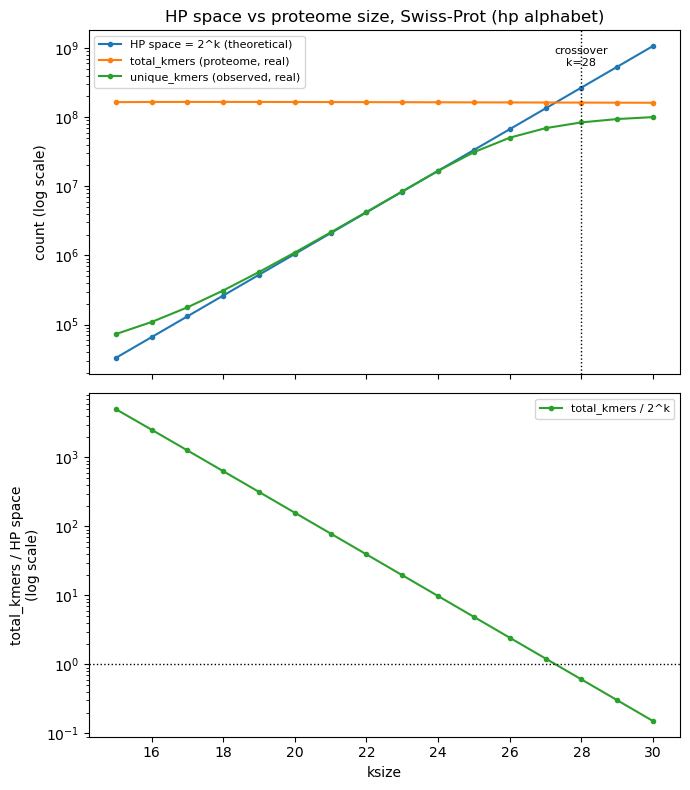

In [11]:
hp_space_df = (
    summary_df.filter(pl.col("moltype") == "hp")
    .sort("ksize")
    .with_columns(
        (2 ** pl.col("ksize")).alias("hp_space"),
    )
    .with_columns(
        (pl.col("total_kmers") / pl.col("hp_space")).alias("total_over_space"),
        (pl.col("unique_kmers") / pl.col("hp_space")).alias("unique_over_space"),
    )
)

# Crossover: first ksize where total_kmers drops below hp_space (ratio crosses 1).
crossover_row = hp_space_df.filter(pl.col("total_over_space") < 1.0).sort("ksize").row(0, named=True)
crossover_k = crossover_row["ksize"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

ax1.plot(hp_space_df["ksize"], hp_space_df["hp_space"], marker="o", markersize=3, label="HP space = 2^k (theoretical)")
ax1.plot(hp_space_df["ksize"], hp_space_df["total_kmers"], marker="o", markersize=3, label="total_kmers (proteome, real)")
ax1.plot(hp_space_df["ksize"], hp_space_df["unique_kmers"], marker="o", markersize=3, label="unique_kmers (observed, real)")
ax1.axvline(crossover_k, color="black", linestyle=":", linewidth=1)
ax1.annotate(f"crossover\nk={crossover_k}", (crossover_k, hp_space_df["hp_space"].max()), fontsize=8, ha="center", va="top")
ax1.set_yscale("log")
ax1.set_ylabel("count (log scale)")
ax1.set_title("HP space vs proteome size, Swiss-Prot (hp alphabet)")
ax1.legend(fontsize=8)

ax2.plot(hp_space_df["ksize"], hp_space_df["total_over_space"], marker="o", markersize=3, color="tab:green", label="total_kmers / 2^k")
ax2.axhline(1.0, color="black", linestyle=":", linewidth=1)
ax2.set_yscale("log")
ax2.set_xlabel("ksize")
ax2.set_ylabel("total_kmers / HP space\n(log scale)")
ax2.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "24_hp_space_vs_proteome_size_vs_ksize.png", dpi=150, bbox_inches="tight")

print(hp_space_df.select("ksize", "hp_space", "total_kmers", "unique_kmers", "total_over_space", "unique_over_space"))


## Figure 6: the negative space -- how much of HP space is never observed

Figure 5's log-scale panels are the right way to see the crossover, but a log scale distorts the *gap* itself: two curves that look a hair's-width apart at the top of a log plot can differ by 10x, while the same pixel gap near the bottom might be 2x. To see the unexplored fraction honestly, plot `unique_kmers / 2^k` -- the fraction of the theoretical HP space actually observed -- on a **linear 0-100% axis**. The area under that curve is "explored"; the area above it, up to 100%, is the negative space: real Swiss-Prot HP patterns that could theoretically exist at that ksize but were never seen even once.

One wrinkle: `unique_kmers` can slightly *exceed* `2^k` for k<=24 (up to 118% at k=18). That's not a bug in the space calculation -- it's the same non-canonical-residue edge effect noted earlier (rare X/U/B/Z/O characters in Swiss-Prot create extra length-k windows that sit outside the strict 2-symbol H/P alphabet). The plot below caps coverage at 100% for display; treat anything shown at the 100% ceiling as "fully saturated," not literally exact.

shape: (16, 5)
┌───────┬────────────┬──────────────┬──────────────┬────────────────────┐
│ ksize ┆ hp_space   ┆ unique_kmers ┆ coverage_pct ┆ negative_space_pct │
│ ---   ┆ ---        ┆ ---          ┆ ---          ┆ ---                │
│ i64   ┆ i32        ┆ i64          ┆ f64          ┆ f64                │
╞═══════╪════════════╪══════════════╪══════════════╪════════════════════╡
│ 15    ┆ 32768      ┆ 72543        ┆ 221.383667   ┆ -121.383667        │
│ 16    ┆ 65536      ┆ 108613       ┆ 165.730286   ┆ -65.730286         │
│ 17    ┆ 131072     ┆ 176936       ┆ 134.991455   ┆ -34.991455         │
│ 18    ┆ 262144     ┆ 310440       ┆ 118.423462   ┆ -18.423462         │
│ 19    ┆ 524288     ┆ 574795       ┆ 109.633446   ┆ -9.633446          │
│ …     ┆ …          ┆ …            ┆ …            ┆ …                  │
│ 26    ┆ 67108864   ┆ 50517302     ┆ 75.276646    ┆ 24.723354          │
│ 27    ┆ 134217728  ┆ 69420759     ┆ 51.722496    ┆ 48.277504          │
│ 28    ┆ 268435456  ┆ 

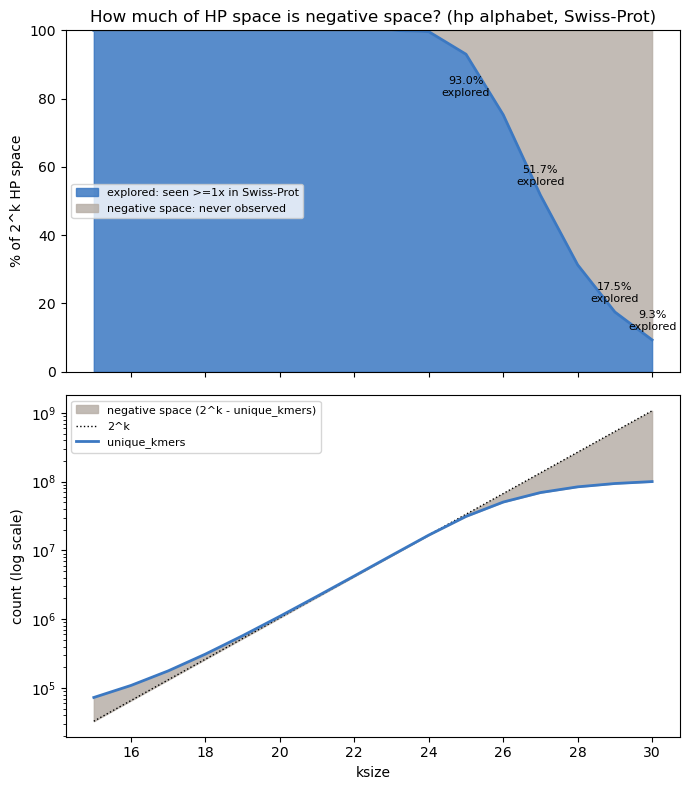

In [12]:
EXPLORED_COLOR = "#3B78C2"  # blue: HP patterns actually observed at least once
NEGATIVE_SPACE_COLOR = "#B8B0A8"  # warm gray: HP patterns that could exist but were never seen

hp_negspace_df = hp_space_df.with_columns((pl.col("unique_over_space") * 100).alias("coverage_pct")).with_columns(
    (100 - pl.col("coverage_pct")).alias("negative_space_pct"),
    pl.min_horizontal(pl.col("unique_over_space") * 100, 100.0).alias("coverage_pct_capped"),
)

ksize = hp_negspace_df["ksize"].to_numpy()
coverage_pct_capped = hp_negspace_df["coverage_pct_capped"].to_numpy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

# Panel 1 (hero view): coverage fraction on a linear 0-100% axis, capped at 100% for
# display (unique_kmers can slightly exceed 2^k at low ksize -- see markdown above).
# The area above the curve, shaded gray, *is* the negative space -- undistorted by log
# scale, so its size on the page tracks its actual size in the data.
ax1.fill_between(ksize, 0, coverage_pct_capped, color=EXPLORED_COLOR, alpha=0.85, label="explored: seen >=1x in Swiss-Prot")
ax1.fill_between(ksize, coverage_pct_capped, 100, color=NEGATIVE_SPACE_COLOR, alpha=0.85, label="negative space: never observed")
ax1.plot(ksize, coverage_pct_capped, color=EXPLORED_COLOR, linewidth=2)

for k_mark in [25, 27, 29, 30]:
    row = hp_negspace_df.filter(pl.col("ksize") == k_mark)
    if row.height == 0:
        continue
    pct = row["coverage_pct_capped"].item()
    below = pct > 85  # keep labels clear of the top frame when the point sits near 100%
    ax1.annotate(
        f"{pct:.1f}%\nexplored",
        (k_mark, pct),
        fontsize=8,
        ha="center",
        va="top" if below else "bottom",
        xytext=(0, -16 if below else 6),
        textcoords="offset points",
        color="black",
    )

ax1.set_ylim(0, 100)
ax1.set_ylabel("% of 2^k HP space")
ax1.set_title("How much of HP space is negative space? (hp alphabet, Swiss-Prot)")
ax1.legend(fontsize=8, loc="center left")

# Panel 2 (magnitude view): same gap in absolute counts, log scale -- shows that even
# though the *fraction* explored looks small only at high ksize, the *absolute* unexplored
# count is already enormous by the crossover.
ax2.fill_between(
    hp_space_df["ksize"], hp_space_df["unique_kmers"], hp_space_df["hp_space"],
    color=NEGATIVE_SPACE_COLOR, alpha=0.85, label="negative space (2^k - unique_kmers)",
)
ax2.plot(hp_space_df["ksize"], hp_space_df["hp_space"], color="black", linewidth=1, linestyle=":", label="2^k")
ax2.plot(hp_space_df["ksize"], hp_space_df["unique_kmers"], color=EXPLORED_COLOR, linewidth=2, label="unique_kmers")
ax2.set_yscale("log")
ax2.set_xlabel("ksize")
ax2.set_ylabel("count (log scale)")
ax2.legend(fontsize=8, loc="upper left")

fig.tight_layout()
fig.savefig(FIG_DIR / "24_hp_space_negative_space.png", dpi=150, bbox_inches="tight")

print(hp_negspace_df.select("ksize", "hp_space", "unique_kmers", "coverage_pct", "negative_space_pct"))


## Figure 7: does negative space predict search accuracy?

Figure 6 shows how much of HP space goes unexplored at each ksize. The open question is whether that negative space is what makes k-mer search work: too little (low ksize, oversaturated) and nearly every k-mer matches everything, so a shared k-mer carries no evidence of homology; too much (high ksize, wildly undersampled) and even true orthologs may fail to share an exact k-mer at all. If that's right, accuracy should be low at both extremes and peak somewhere in between -- not simply rise or fall monotonically with negative space.

This uses real accuracy data, not a proxy: `200_rbh_f1.<encoding>.k<ksize>.csv` from the human-mouse ortholog reciprocal-best-hit benchmark (`nextflow-runs/human-mouse-gencode-orthologs/`), which is a live, actively-running benchmark as of this notebook -- re-run this cell later for more ksizes as they land. `kmerseek_F1` is the headline metric: F1 of kmerseek's own hit-calling against the RBH ortholog set, i.e. does search actually find the right pairs without flooding them with false positives.

Encoding-name mapping: the RBH-F1 pipeline names encodings with dashes (`hp-pbotc-1st-ed`) and, for the bare `hp` alphabet specifically, calls it `hp-lehninger` rather than `hp` -- confirmed earlier in this notebook that `hp`'s table (sourmash's built-in `HPTABLE`) and Lehninger's table are the identical partition, so this is the same alphabet under a different name, not a substitution. `hp-lehninger` also has much fuller ksize coverage (18-30) than the sparse `hp` runs (21,22,24,26-30) available so far, so it's used here in place of `hp`.

In [13]:
RBH_F1_DIR = Path.home() / "data" / "gencode" / "results-human-mouse-orthologs" / "200_rbh_f1"

# notebook moltype -> RBH-F1 pipeline's encoding name
RBH_ENCODING_BY_MOLTYPE = {
    "hp": "hp-lehninger",
    "hp_kyte_doolittle": "hp-kyte-doolittle",
    "hp_lehninger_plus_c": "hp-lehninger-plus-c",
    "hp_pbotc_1st_ed": "hp-pbotc-1st-ed",
    "hp_thomas_dill": "hp-thomas-dill",
    "hp_thomas_dill_no_c": "hp-thomas-dill-no-c",
}

# Some combos are truncated partial runs (the RBH-F1 benchmark is actively running as of
# this notebook -- see feedback_bulk_download_stalls-style truncated-run history). Their
# n_genes_scope is far below the full ~19,694-gene scope, so their precision/recall aren't
# comparable to the rest -- drop them rather than let them masquerade as real ksize effects.
MIN_GENES_SCOPE = 15_000

# Negative space per (moltype, ksize) for every HP alphabet -- same computation as
# Figure 6, generalized from "hp" alone to the full HP family.
negspace_all_df = (
    summary_df.filter(pl.col("moltype").is_in(RBH_ENCODING_BY_MOLTYPE))
    .sort(["moltype", "ksize"])
    .with_columns((2 ** pl.col("ksize")).alias("hp_space"))
    .with_columns((pl.col("unique_kmers") / pl.col("hp_space") * 100).alias("coverage_pct"))
    .with_columns(pl.min_horizontal(pl.col("coverage_pct"), 100.0).alias("coverage_pct_capped"))
    .with_columns((100 - pl.col("coverage_pct_capped")).alias("negative_space_pct"))
)

# Real accuracy data: one row per (encoding, ksize) already present in RBH_F1_DIR.
accuracy_records = []
excluded = []
for moltype, rbh_encoding in RBH_ENCODING_BY_MOLTYPE.items():
    for csv_path in sorted(RBH_F1_DIR.glob(f"200_rbh_f1.{rbh_encoding}.k*.csv")):
        row = pl.read_csv(csv_path)
        if row.height == 0:
            continue  # mid-write by the still-running benchmark; skip and pick it up on a later re-run
        n_genes_scope = int(row["n_genes_scope"][0])
        if n_genes_scope < MIN_GENES_SCOPE:
            excluded.append((moltype, int(row["ksize"][0]), n_genes_scope))
            continue
        accuracy_records.append(
            {
                "moltype": moltype,
                "ksize": int(row["ksize"][0]),
                "n_genes_scope": n_genes_scope,
                "kmerseek_F1": float(row["kmerseek_F1"][0]),
                "roc_auc": float(row["roc_auc"][0]),
            }
        )
accuracy_df = pl.DataFrame(accuracy_records)

print(f"Excluded {len(excluded)} truncated-scope combo(s): {excluded}")

negspace_accuracy_df = negspace_all_df.join(accuracy_df, on=["moltype", "ksize"], how="inner").sort(["moltype", "ksize"])
print(f"{negspace_accuracy_df.shape[0]} (moltype, ksize) combos with both spectrum and full-scope accuracy data")
print(negspace_accuracy_df.group_by("moltype").agg(pl.col("ksize").min().alias("k_min"), pl.col("ksize").max().alias("k_max"), pl.len().alias("n")))


Excluded 3 truncated-scope combo(s): [('hp_kyte_doolittle', 16, 78), ('hp_kyte_doolittle', 18, 999), ('hp_thomas_dill', 23, 11484)]
70 (moltype, ksize) combos with both spectrum and full-scope accuracy data
shape: (6, 4)
┌─────────────────────┬───────┬───────┬─────┐
│ moltype             ┆ k_min ┆ k_max ┆ n   │
│ ---                 ┆ ---   ┆ ---   ┆ --- │
│ str                 ┆ i64   ┆ i64   ┆ u32 │
╞═════════════════════╪═══════╪═══════╪═════╡
│ hp                  ┆ 18    ┆ 30    ┆ 13  │
│ hp_kyte_doolittle   ┆ 20    ┆ 30    ┆ 11  │
│ hp_lehninger_plus_c ┆ 18    ┆ 30    ┆ 13  │
│ hp_pbotc_1st_ed     ┆ 19    ┆ 30    ┆ 12  │
│ hp_thomas_dill      ┆ 20    ┆ 30    ┆ 10  │
│ hp_thomas_dill_no_c ┆ 20    ┆ 30    ┆ 11  │
└─────────────────────┴───────┴───────┴─────┘


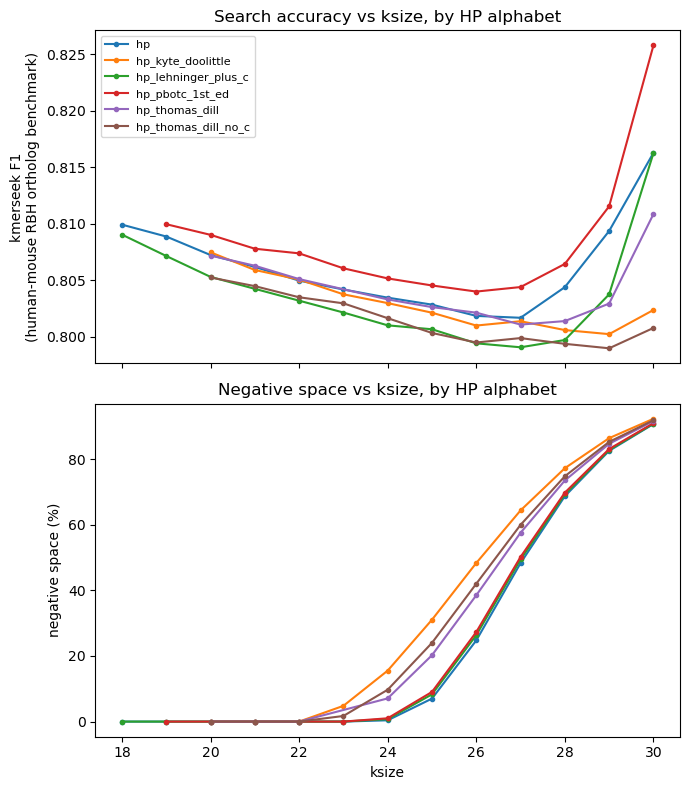

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

for moltype, group in negspace_accuracy_df.group_by("moltype", maintain_order=True):
    moltype = moltype[0]
    g = group.sort("ksize")
    line, = ax1.plot(g["ksize"], g["kmerseek_F1"], marker="o", markersize=3, label=moltype)
    ax2.plot(g["ksize"], g["negative_space_pct"], marker="o", markersize=3, color=line.get_color())

ax1.set_ylabel("kmerseek F1\n(human-mouse RBH ortholog benchmark)")
ax1.set_title("Search accuracy vs ksize, by HP alphabet")
ax1.legend(fontsize=8)

ax2.set_xlabel("ksize")
ax2.set_ylabel("negative space (%)")
ax2.set_title("Negative space vs ksize, by HP alphabet")

fig.tight_layout()
fig.savefig(FIG_DIR / "24_accuracy_and_negative_space_vs_ksize.png", dpi=150, bbox_inches="tight")


The panel-vs-ksize view above puts accuracy and negative space side by side, but ksize is a confound: both curves move with ksize, so it's hard to tell whether negative space is *doing* anything or the two are just coincidentally both functions of ksize. The direct test is to plot accuracy against negative space itself, ksize implicit as the path along each line.

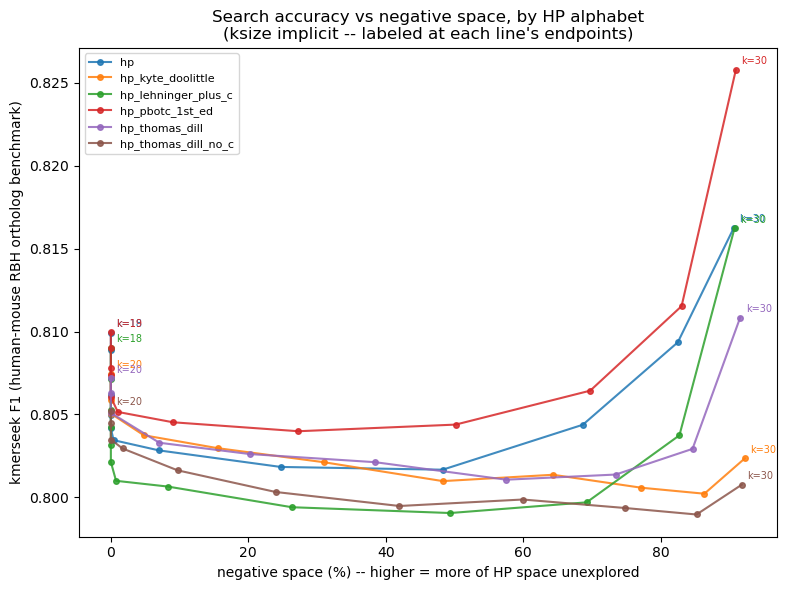

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

for moltype, group in negspace_accuracy_df.group_by("moltype", maintain_order=True):
    moltype = moltype[0]
    g = group.sort("negative_space_pct")
    line, = ax.plot(g["negative_space_pct"], g["kmerseek_F1"], marker="o", markersize=4, label=moltype, alpha=0.85)
    # Label the ksize endpoints so the direction of travel along the curve is legible.
    first, last = g.row(0, named=True), g.row(-1, named=True)
    for row in (first, last):
        ax.annotate(
            f"k={row['ksize']}",
            (row["negative_space_pct"], row["kmerseek_F1"]),
            fontsize=7,
            color=line.get_color(),
            xytext=(4, 4),
            textcoords="offset points",
        )

ax.set_xlabel("negative space (%) -- higher = more of HP space unexplored")
ax.set_ylabel("kmerseek F1 (human-mouse RBH ortholog benchmark)")
ax.set_title("Search accuracy vs negative space, by HP alphabet\n(ksize implicit -- labeled at each line's endpoints)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "24_accuracy_vs_negative_space.png", dpi=150, bbox_inches="tight")


### What this actually shows

Not a sweet spot in the middle. All 6 alphabets trace the same shape: F1 is highest right where negative space is ~0% (k=18-19, fully saturated), *dips* to a shallow minimum somewhere in the 40-70% negative-space range (roughly k=23-27), then climbs again toward the highest negative-space values tested (k=28-30) -- for `hp_pbotc_1st_ed` and `hp`/`hp_lehninger_plus_c`, that climb actually overshoots the low-ksize starting point. That's a valley, not a peak, and it's the opposite of "accuracy is worst at both extremes."

Two things worth being careful about before reading much into this:

- **The effect is real but small.** The whole range is F1 = 0.799-0.826 -- about 3 percentage points from best to worst. Compare that to the ~13-point precision/recall spread already visible within a single ksize (e.g. `hp_kyte_doolittle` k=20's kmerseek_precision=0.96 vs kmerseek_recall=0.70). Negative space is not the dominant lever on accuracy in this benchmark.
- **This only covers k=18-30, i.e. negative space from ~0% to ~93%.** The regime the original hypothesis worries about most -- k so small that nearly everything collides (negative space near 0% *because there's no room to be selective*, e.g. k=1-10) -- isn't in this data at all. It's possible the true low-k end of the curve falls off a cliff below k=18 and we're only seeing the flat-then-rising right-hand two-thirds of a real peak. That would need RBH-F1 runs at k<18 to check, which the benchmark doesn't currently sweep for the HP family (it starts at k=15 in the spectra but the RBH-F1 accuracy runs only reach down to k=16-20 depending on alphabet).